# Training a Generative Adversarial Network on MNIST

The goal of this assignment is to train a GAN (Generative Adversarial Network) model using PyTorch on the MNIST dataset to generate digit images. The MNIST dataset consists of grayscale handwritten digit images with a resolution of 28×28 pixels.

For this task, you are required to complete the following steps:

> 1. Implement the main components in the Generator and Discriminator. (in Step-2)
> 2. Define the loss function and optimizers (in Step 3).
> 3. Complete the training loop (in Step 4), including: \
    (a) Labels for real images and fake images when training the discriminator, \
    (b) Calculation of the discriminator’s loss for real images, \
    (c) Calculation of the discriminator’s loss for fake images, \
    (d) Calculation of the generator’s loss.
> 4. Plot the training loss curves (in Step 5).
> 5. Generate and save 25 images using the trained generator (in Step 6).

In [ ]:
"""
Step 1: import packages and load datasets
        For MNIST dataset, we can directly load it from torchvision
"""
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import matplotlib.pyplot as plt
import numpy as np
import os
import PIL.Image as Image

# Hyper-parameters
batch_size = 128
latent_dim = 100
lr = 0.0002
epochs = 50
device = "cpu"  # If your device has a GPU, you can change 'cpu' to 'cuda'.


# Create directories for saving the outputs
os.makedirs("gan_images", exist_ok=True)
os.makedirs("gan_models", exist_ok=True)

# Data processing
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Load MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


100%|██████████| 9.91M/9.91M [00:00<00:00, 17.7MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 479kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.9MB/s]


In [ ]:
"""
Step 2: implement the generator and discriminator
"""

class Generator(nn.Module):
    def __init__(self, latent_dim=100):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, 512),
            nn.ReLU(inplace=True),
            nn.Linear(512, 784),
            nn.Tanh()
        )

    def forward(self, z):
        out = self.model(z)
        return out.view(z.size(0), 1, 28, 28)


class Discriminator(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = nn.Sequential(
            nn.Linear(784, 512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(512, 256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(256, 1),
            nn.Sigmoid()
        )

    def forward(self, img):
        flat = img.view(img.size(0), -1)
        return self.model(flat).squeeze(1)


generator = Generator(latent_dim).to(device)
discriminator = Discriminator().to(device)

In [ ]:
"""
Step 3: define the loss functions and optimizers for the generator and discriminator
"""

# Loss function
adversarial_loss = nn.BCELoss()

# Optimizers
optimizer_G = optim.Adam(generator.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = optim.Adam(discriminator.parameters(), lr=lr, betas=(0.5, 0.999))

In [ ]:
"""
Step 4: implement entire process of training a GAN
"""

d_losses = []
g_losses = []

for epoch in range(epochs):
    for batch_idx, (imgs, _) in enumerate(train_loader):
        real_imgs = imgs.to(device)

        # Labels
        valid = torch.ones(imgs.size(0), device=device)
        fake  = torch.zeros(imgs.size(0), device=device)

        # Train Discriminator
        for p in generator.parameters(): p.requires_grad = False
        for p in discriminator.parameters(): p.requires_grad = True

        optimizer_D.zero_grad()
        real_pred = discriminator(real_imgs)
        loss_real = adversarial_loss(real_pred, valid)

        z = torch.randn(imgs.size(0), latent_dim, device=device)
        gen_imgs = generator(z)
        fake_pred = discriminator(gen_imgs.detach())
        loss_fake = adversarial_loss(fake_pred, fake)

        d_loss = (loss_real + loss_fake) / 2
        d_loss.backward()
        optimizer_D.step()

        # Train Generator
        for p in discriminator.parameters(): p.requires_grad = False
        for p in generator.parameters():     p.requires_grad = True

        optimizer_G.zero_grad()
        z = torch.randn(imgs.size(0), latent_dim, device=device)
        gen_imgs = generator(z)
        fake_pred = discriminator(gen_imgs)
        g_loss = adversarial_loss(fake_pred, valid)
        g_loss.backward()
        optimizer_G.step()

        d_losses.append(d_loss.item())
        g_losses.append(g_loss.item())

        if batch_idx % 100 == 0:
            print(f"[Epoch {epoch}/{epochs}] [Batch {batch_idx}/{len(train_loader)}] "
                  f"[D loss: {d_loss.item():.4f}] [G loss: {g_loss.item():.4f}]")

    # Save images and checkpoints each epoch
    save_image(gen_imgs.data[:25], f"gan_images/epoch_{epoch}.png", nrow=5, normalize=True)
    torch.save(generator.state_dict(),     f"gan_models/generator_epoch_{epoch}.pth")
    torch.save(discriminator.state_dict(), f"gan_models/discriminator_epoch_{epoch}.pth")

[Epoch 0/50] [Batch 0/469] [D loss: 0.7027] [G loss: 0.7243]
[Epoch 0/50] [Batch 100/469] [D loss: 0.4465] [G loss: 1.6124]
[Epoch 0/50] [Batch 200/469] [D loss: 0.6767] [G loss: 0.9425]
[Epoch 0/50] [Batch 300/469] [D loss: 0.3181] [G loss: 2.0350]
[Epoch 0/50] [Batch 400/469] [D loss: 0.2295] [G loss: 3.4634]
[Epoch 1/50] [Batch 0/469] [D loss: 0.4008] [G loss: 0.9440]
[Epoch 1/50] [Batch 100/469] [D loss: 0.1352] [G loss: 4.1424]
[Epoch 1/50] [Batch 200/469] [D loss: 0.2273] [G loss: 2.7473]
[Epoch 1/50] [Batch 300/469] [D loss: 0.2651] [G loss: 2.1273]
[Epoch 1/50] [Batch 400/469] [D loss: 0.1696] [G loss: 3.2129]
[Epoch 2/50] [Batch 0/469] [D loss: 0.4286] [G loss: 5.9605]
[Epoch 2/50] [Batch 100/469] [D loss: 0.2327] [G loss: 4.3641]
[Epoch 2/50] [Batch 200/469] [D loss: 0.1817] [G loss: 4.3145]
[Epoch 2/50] [Batch 300/469] [D loss: 0.2389] [G loss: 4.3393]
[Epoch 2/50] [Batch 400/469] [D loss: 0.2979] [G loss: 4.1862]
[Epoch 3/50] [Batch 0/469] [D loss: 0.2605] [G loss: 4.3324]


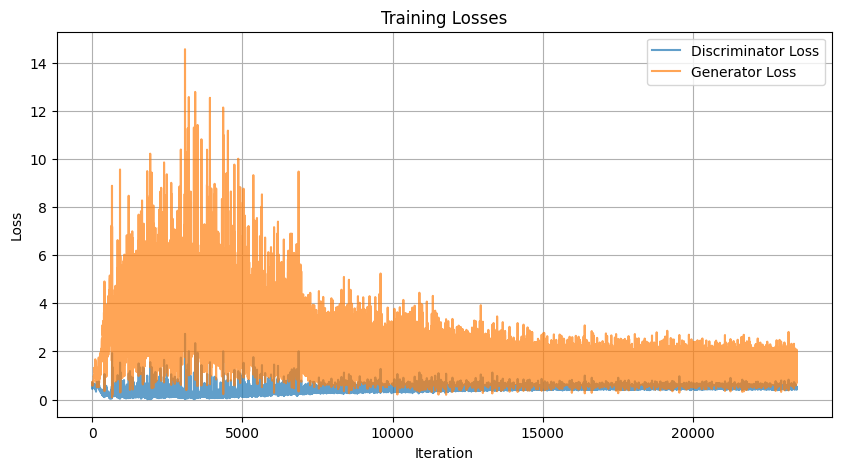

In [ ]:
"""
Step 5: Plot the training loss curve
"""

plt.figure(figsize=(10, 5))
plt.plot(d_losses, label="Discriminator Loss", alpha=0.7)
plt.plot(g_losses, label="Generator Loss", alpha=0.7)
plt.title("Training Losses")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

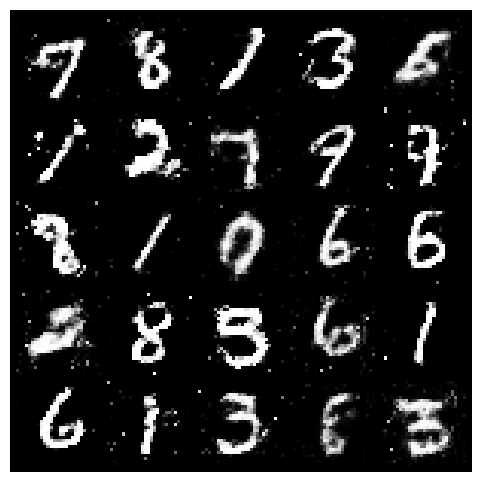

In [ ]:
"""
Step 6: Generate images using a trained generator, and save them
"""

# Generate and save 25 samples
generator.eval()
with torch.no_grad():
    z = torch.randn(25, latent_dim, device=device)
    gen_imgs = generator(z)
    save_image(gen_imgs, "generated_25_images.png", nrow=5, normalize=True, value_range=(-1, 1))

from torchvision.utils import make_grid
grid = make_grid(gen_imgs, nrow=5, normalize=True, value_range=(-1, 1))
np_grid = grid.cpu().numpy().transpose(1, 2, 0)
plt.figure(figsize=(6, 6))
plt.imshow(np_grid, cmap="gray")
plt.axis("off")
plt.show()

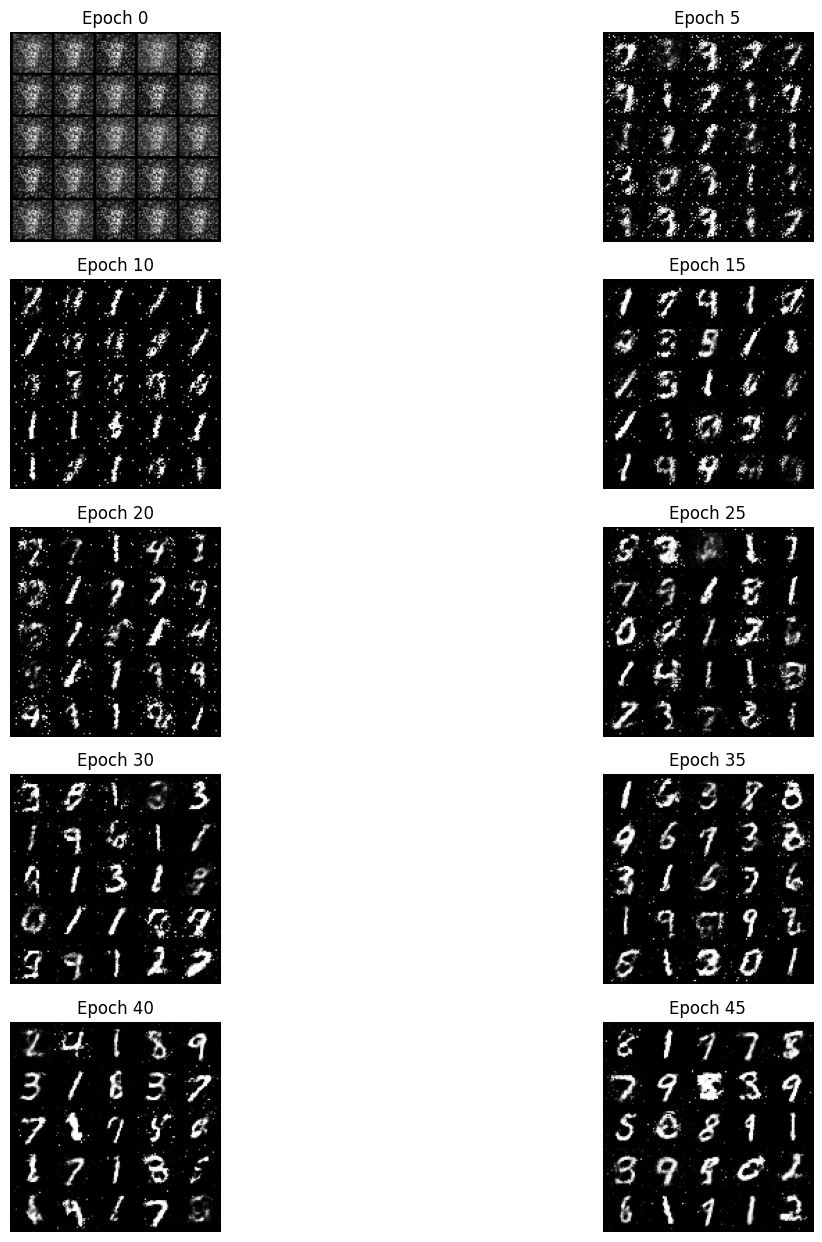

In [ ]:
"""
Part‑2.A: Extract generated images from epochs 0, 5, 10, ..., 50
"""

import os
import matplotlib.pyplot as plt
from PIL import Image

epochs_to_show = list(range(0, 51, 5))
image_paths = [f"gan_images/epoch_{e}.png" for e in epochs_to_show]

plt.figure(figsize=(12, 15))

for i, path in enumerate(image_paths):
    if os.path.exists(path):
        img = Image.open(path)
        plt.subplot(6, 2, i + 1)
        plt.imshow(img, cmap="gray")
        plt.title(f"Epoch {epochs_to_show[i]}")
        plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
"""
Part‑2.B: Train GAN with different batch sizes.
Batch sizes: 128, 256, 512, 1024
This cell defines a reusable training function; call it multiple times.
"""

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image

def train_gan_with_batch(batch_size, epochs=20, lr=0.0002):
    print(f"\n=== Training GAN with batch size {batch_size} ===")

    # dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # simple Generator / Discriminator from Part 1
    class G(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(100,256), nn.ReLU(),
                nn.Linear(256,512), nn.ReLU(),
                nn.Linear(512,784), nn.Tanh()
            )
        def forward(self,z):
            x = self.net(z)
            return x.view(-1,1,28,28)

    class D(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(784,512), nn.LeakyReLU(0.2),
                nn.Linear(512,256), nn.LeakyReLU(0.2),
                nn.Linear(256,1), nn.Sigmoid()
            )
        def forward(self,x):
            return self.net(x.view(x.size(0), -1))

    G_model, D_model = G().cuda(), D().cuda()
    loss_fn = nn.BCELoss()
    opt_G = optim.Adam(G_model.parameters(), lr=lr, betas=(0.5,0.999))
    opt_D = optim.Adam(D_model.parameters(), lr=lr, betas=(0.5,0.999))

    for epoch in range(epochs):
        for real, _ in loader:
            real = real.cuda()
            batch = real.size(0)
            labels_real = torch.ones(batch,1).cuda()
            labels_fake = torch.zeros(batch,1).cuda()

            # --- train D ---
            z = torch.randn(batch, 100).cuda()
            fake = G_model(z).detach()
            loss_D = (loss_fn(D_model(real), labels_real) +
                      loss_fn(D_model(fake), labels_fake)) * 0.5
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # --- train G ---
            z = torch.randn(batch, 100).cuda()
            fake = G_model(z)
            loss_G = loss_fn(D_model(fake), labels_real)
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

        print(f"Epoch {epoch}: D={loss_D.item():.3f}, G={loss_G.item():.3f}")

    # generate final images
    z = torch.randn(25,100).cuda()
    out = G_model(z)
    save_image(out, f"batch_{batch_size}_samples.png", nrow=5, normalize=True)

    print(f"Saved: batch_{batch_size}_samples.png")

In [ ]:
# Run experiments
for b in [128, 256, 512, 1024]:
    train_gan_with_batch(b)


=== Training GAN with batch size 128 ===
Epoch 0: D=0.188, G=2.301
Epoch 1: D=0.168, G=5.363
Epoch 2: D=0.131, G=4.594
Epoch 3: D=0.158, G=2.873
Epoch 4: D=0.135, G=3.501
Epoch 5: D=0.087, G=2.309
Epoch 6: D=0.045, G=3.356
Epoch 7: D=0.231, G=3.332
Epoch 8: D=0.117, G=4.150
Epoch 9: D=0.165, G=2.362
Epoch 10: D=0.165, G=2.240
Epoch 11: D=0.188, G=4.958
Epoch 12: D=0.284, G=2.166
Epoch 13: D=0.234, G=2.057
Epoch 14: D=0.255, G=3.028
Epoch 15: D=1.389, G=1.361
Epoch 16: D=0.224, G=3.292
Epoch 17: D=0.320, G=2.067
Epoch 18: D=0.451, G=0.798
Epoch 19: D=0.316, G=1.428
Saved: batch_128_samples.png

=== Training GAN with batch size 256 ===
Epoch 0: D=0.455, G=1.384
Epoch 1: D=0.273, G=1.657
Epoch 2: D=0.298, G=4.257
Epoch 3: D=0.209, G=1.610
Epoch 4: D=0.142, G=4.785
Epoch 5: D=0.420, G=4.864
Epoch 6: D=0.191, G=3.556
Epoch 7: D=0.099, G=4.207
Epoch 8: D=0.280, G=4.190
Epoch 9: D=0.172, G=4.409
Epoch 10: D=0.044, G=3.224
Epoch 11: D=0.175, G=2.580
Epoch 12: D=0.122, G=1.031
Epoch 13: D=0.20

In [ ]:
"""
Part‑2.C: Compare StepLR and Warmup+Cosine learning rate schedules
Using batch_size=1024 (worst case)
"""

from torch.optim.lr_scheduler import StepLR, LinearLR, CosineAnnealingLR

def train_gan_scheduler(scheduler_type, epochs=20, batch_size=1024):
    print(f"\n=== Training with Scheduler: {scheduler_type} ===")

    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    class G(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(100,256), nn.ReLU(),
                                     nn.Linear(256,512), nn.ReLU(),
                                     nn.Linear(512,784), nn.Tanh())
        def forward(self,z): return self.net(z).view(-1,1,28,28)

    class D(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(nn.Linear(784,512), nn.LeakyReLU(0.2),
                                     nn.Linear(512,256), nn.LeakyReLU(0.2),
                                     nn.Linear(256,1), nn.Sigmoid())
        def forward(self,x): return self.net(x.view(x.size(0), -1))

    G_model, D_model = G().cuda(), D().cuda()
    loss_fn = nn.BCELoss()
    opt_G = optim.Adam(G_model.parameters(), lr=0.0002, betas=(0.5,0.999))
    opt_D = optim.Adam(D_model.parameters(), lr=0.0002, betas=(0.5,0.999))

    if scheduler_type == "step":
        sched_G = StepLR(opt_G, step_size=10, gamma=0.1)
        sched_D = StepLR(opt_D, step_size=10, gamma=0.1)
    else:
        warm_G = LinearLR(opt_G, start_factor=0.1, total_iters=5)
        warm_D = LinearLR(opt_D, start_factor=0.1, total_iters=5)
        cos_G = CosineAnnealingLR(opt_G, T_max=epochs-5)
        cos_D = CosineAnnealingLR(opt_D, T_max=epochs-5)

    for epoch in range(epochs):
        for real, _ in loader:
            real = real.cuda()
            b = real.size(0)
            y_real = torch.ones(b,1).cuda()
            y_fake = torch.zeros(b,1).cuda()

            z = torch.randn(b,100).cuda()
            fake = G_model(z).detach()
            loss_D = (loss_fn(D_model(real), y_real) +
                      loss_fn(D_model(fake), y_fake)) * 0.5
            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            z = torch.randn(b,100).cuda()
            fake = G_model(z)
            loss_G = loss_fn(D_model(fake), y_real)
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

        # update scheduler
        if scheduler_type == "step":
            sched_G.step()
            sched_D.step()
        else:
            if epoch < 5:
                warm_G.step()
                warm_D.step()
            else:
                cos_G.step()
                cos_D.step()

        print(f"Epoch {epoch}: D={loss_D.item():.3f}, G={loss_G.item():.3f}")

    # save samples
    z = torch.randn(25,100).cuda()
    out = G_model(z)
    save_image(out, f"sched_{scheduler_type}_samples.png", nrow=5, normalize=True)

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR, LinearLR, CosineAnnealingLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torchvision.utils import save_image
import math

def train_gan_scheduler_verbose(scheduler_type="warmup_cosine", epochs=10, batch_size=1024):
    print("\n==============================")
    print(f" STARTING TRAINING WITH SCHEDULER = {scheduler_type.upper()}")
    print("==============================\n")

    # dataset
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))
    ])
    dataset = datasets.MNIST(root="./data", train=True, download=True, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    # simple networks
    class G(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(100,256), nn.ReLU(),
                nn.Linear(256,512), nn.ReLU(),
                nn.Linear(512,784), nn.Tanh()
            )
        def forward(self,z):
            return self.net(z).view(-1,1,28,28)

    class D(nn.Module):
        def __init__(self):
            super().__init__()
            self.net = nn.Sequential(
                nn.Linear(784,512), nn.LeakyReLU(0.2),
                nn.Linear(512,256), nn.LeakyReLU(0.2),
                nn.Linear(256,1), nn.Sigmoid()
            )
        def forward(self,x):
            return self.net(x.view(x.size(0), -1))

    Gm, Dm = G().cuda(), D().cuda()
    loss_fn = nn.BCELoss()

    opt_G = optim.Adam(Gm.parameters(), lr=0.0002, betas=(0.5, 0.999))
    opt_D = optim.Adam(Dm.parameters(), lr=0.0002, betas=(0.5, 0.999))

    # schedulers
    if scheduler_type == "step":
        sched_G = StepLR(opt_G, step_size=5, gamma=0.5)
        sched_D = StepLR(opt_D, step_size=5, gamma=0.5)
        warmup_steps = None
        print("Using StepLR: step_size=5, gamma=0.5")

    elif scheduler_type == "warmup_cosine":
        warmup_steps = 3
        sched_G_warm = LinearLR(opt_G, start_factor=0.1, total_iters=warmup_steps)
        sched_D_warm = LinearLR(opt_D, start_factor=0.1, total_iters=warmup_steps)
        sched_G_cos = CosineAnnealingLR(opt_G, T_max=epochs - warmup_steps)
        sched_D_cos = CosineAnnealingLR(opt_D, T_max=epochs - warmup_steps)
        print("Using Warmup (3 epochs) + Cosine Annealing")

    print("\n--- START TRAINING ---\n")

    total_iters = 0

    for epoch in range(epochs):
        print(f"\n=== Epoch {epoch+1}/{epochs} ===")

        for i, (real, _) in enumerate(loader):
            total_iters += 1
            real = real.cuda()
            b = real.size(0)

            real_label = torch.ones(b,1).cuda()
            fake_label = torch.zeros(b,1).cuda()

            # ---- Train D ----
            z = torch.randn(b,100).cuda()
            fake = Gm(z).detach()

            loss_D_real = loss_fn(Dm(real), real_label)
            loss_D_fake = loss_fn(Dm(fake), fake_label)
            loss_D = 0.5*(loss_D_real + loss_D_fake)

            opt_D.zero_grad()
            loss_D.backward()
            opt_D.step()

            # ---- Train G ----
            z = torch.randn(b,100).cuda()
            fake = Gm(z)

            loss_G = loss_fn(Dm(fake), real_label)
            opt_G.zero_grad()
            loss_G.backward()
            opt_G.step()

            # frequent mid-epoch output
            if i % 10 == 0:
                print(f"[Iter {total_iters:5d}]  D_loss={loss_D.item():.4f}  G_loss={loss_G.item():.4f}")

        # end of epoch scheduling
        if scheduler_type == "step":
            sched_G.step()
            sched_D.step()
        else:
            if epoch < warmup_steps:
                sched_G_warm.step()
                sched_D_warm.step()
                print(f" Warmup step: new LR_G={opt_G.param_groups[0]['lr']:.6f}, LR_D={opt_D.param_groups[0]['lr']:.6f}")
            else:
                sched_G_cos.step()
                sched_D_cos.step()
                print(f" Cosine step: new LR_G={opt_G.param_groups[0]['lr']:.6f}, LR_D={opt_D.param_groups[0]['lr']:.6f}")

        # sample image each epoch
        z = torch.randn(25,100).cuda()
        imgs = Gm(z)
        filename = f"sched_{scheduler_type}_epoch{epoch+1}.png"
        save_image(imgs, filename, nrow=5, normalize=True)
        print(f" Saved Sample Image: {filename}")

    print("\n=== TRAINING COMPLETE ===")
    print("Final image samples saved.")

In [ ]:
# Try step scheduler with tons of printed output
train_gan_scheduler_verbose("step", epochs=5, batch_size=1024)


 STARTING TRAINING WITH SCHEDULER = STEP

Using StepLR: step_size=5, gamma=0.5

--- START TRAINING ---


=== Epoch 1/5 ===
[Iter     1]  D_loss=0.7056  G_loss=0.7045
[Iter    11]  D_loss=0.4872  G_loss=0.5552
[Iter    21]  D_loss=0.5497  G_loss=0.6167
[Iter    31]  D_loss=0.6086  G_loss=0.6444
[Iter    41]  D_loss=0.6649  G_loss=0.6709
[Iter    51]  D_loss=0.5986  G_loss=0.8825
 Saved Sample Image: sched_step_epoch1.png

=== Epoch 2/5 ===
[Iter    60]  D_loss=0.6184  G_loss=0.8992
[Iter    70]  D_loss=0.6433  G_loss=0.9382
[Iter    80]  D_loss=0.5302  G_loss=1.2017
[Iter    90]  D_loss=0.6216  G_loss=1.0869
[Iter   100]  D_loss=0.5015  G_loss=1.3548
[Iter   110]  D_loss=0.5208  G_loss=1.2255
 Saved Sample Image: sched_step_epoch2.png

=== Epoch 3/5 ===
[Iter   119]  D_loss=0.4645  G_loss=1.2534
[Iter   129]  D_loss=0.5323  G_loss=1.0386
[Iter   139]  D_loss=0.5498  G_loss=0.9303
[Iter   149]  D_loss=0.6398  G_loss=0.8106
[Iter   159]  D_loss=0.6493  G_loss=0.8240
[Iter   169]  D_loss=